<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Generative-Deep-Learning/blob/main/scripts/latent_space_random_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# @title Gaussian noise generative demo

"""
정규분포(Gaussian) Random Noise를 활용한 생성모델링(Generative Modeling) 예제
------------------------------------------------------------------------
업로드된 이미지의 흐름을 그대로 재현(Generative Model)

    Training data --training--> Generative Model <--sampling-- Random noise
                                        |
                                        v
                                 Generated sample

핵심 아이디어:
1. Random noise z 는 표준정규분포 N(0, I) 에서 샘플링

2. "Generative Model"은 이 노이즈 벡터 z를 입력받아 데이터 공간(이미지 등)으로
   매핑(mapping)하는 함수 G(z) (실제로는 VAE의 decoder, GAN의 generator,
   Diffusion의 denoiser가 이 역할을 담당)

3. 여기서는 실제 학습된 VAE/GAN 대신, 개념을 보여주기 위해 고정된 랜덤 가중치를
   갖는 간단한 매핑 함수(고정 랜덤 신경망)를 사용해 노이즈 -> 이미지 형태의
   패턴을 생성

4. z가 바뀔 때마다 다른 "샘플"이 만들어지는 것을 확인
"""

'\n정규분포(Gaussian) Random Noise를 활용한 생성모델링(Generative Modeling) 예제\n------------------------------------------------------------------------\n업로드된 이미지의 흐름을 그대로 재현합니다.\n \n    Training data --training--> Generative Model <--sampling-- Random noise\n                                        |\n                                        v\n                                 Generated sample\n \n핵심 아이디어:\n1. Random noise z 는 표준정규분포 N(0, I) 에서 샘플링합니다.\n2. "Generative Model"은 이 노이즈 벡터 z를 입력받아 데이터 공간(이미지 등)으로\n   매핑(mapping)하는 함수 G(z) 입니다. (실제로는 VAE의 decoder, GAN의 generator,\n   Diffusion의 denoiser가 이 역할을 합니다.)\n3. 여기서는 실제 학습된 VAE/GAN 대신, 개념을 보여주기 위해 고정된 랜덤 가중치를\n   갖는 간단한 매핑 함수(고정 랜덤 신경망)를 사용해 노이즈 -> 이미지 형태의\n   패턴을 생성합니다. z가 바뀔 때마다 다른 "샘플"이 만들어지는 것을 확인할 수 있습니다.\n \n필요 라이브러리: numpy, matplotlib\n'

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 재현성을 위한 시드 고정
rng = np.random.default_rng(seed=42)

# ------------------------------------------------------------------
# 1. Random noise 정의: 표준정규분포 N(0, 1) 에서 샘플링
# ------------------------------------------------------------------
latent_dim = 32          # 노이즈 벡터(latent vector)의 차원
n_samples = 8             # 생성할 샘플 개수
img_size = 28              # 생성할 "이미지"의 한 변 크기 (28x28)

# z ~ N(0, I)  : 평균 0, 표준편차 1인 정규분포에서 샘플링
z = rng.normal(loc=0.0, scale=1.0, size=(n_samples, latent_dim))
z

array([[ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
        -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393,
         0.87939797,  0.77779194,  0.0660307 ,  1.12724121,  0.46750934,
        -0.85929246,  0.36875078, -0.9588826 ,  0.8784503 , -0.04992591,
        -0.18486236, -0.68092954,  1.22254134, -0.15452948, -0.42832782,
        -0.35213355,  0.53230919,  0.36544406,  0.41273261,  0.430821  ,
         2.1416476 , -0.40641502],
       [-0.51224273, -0.81377273,  0.61597942,  1.12897229, -0.11394746,
        -0.84015648, -0.82448122,  0.65059279,  0.74325417,  0.54315427,
        -0.66550971,  0.23216132,  0.11668581,  0.2186886 ,  0.87142878,
         0.22359555,  0.67891356,  0.06757907,  0.2891194 ,  0.63128823,
        -1.45715582, -0.31967122, -0.47037265, -0.63887785, -0.27514225,
         1.49494131, -0.86583112,  0.96827835, -1.68286977, -0.33488503,
         0.16275307,  0.58622233],
       [ 0.71122658,  0.79334724, -0.34872507, -0.4623

In [19]:
print("Random noise (latent vector) shape:", z.shape)
print("Random noise 통계  ->  mean: {:.4f}, std: {:.4f}".format(z.mean(), z.std()))

Random noise (latent vector) shape: (8, 32)
Random noise 통계  ->  mean: -0.0426, std: 0.9384


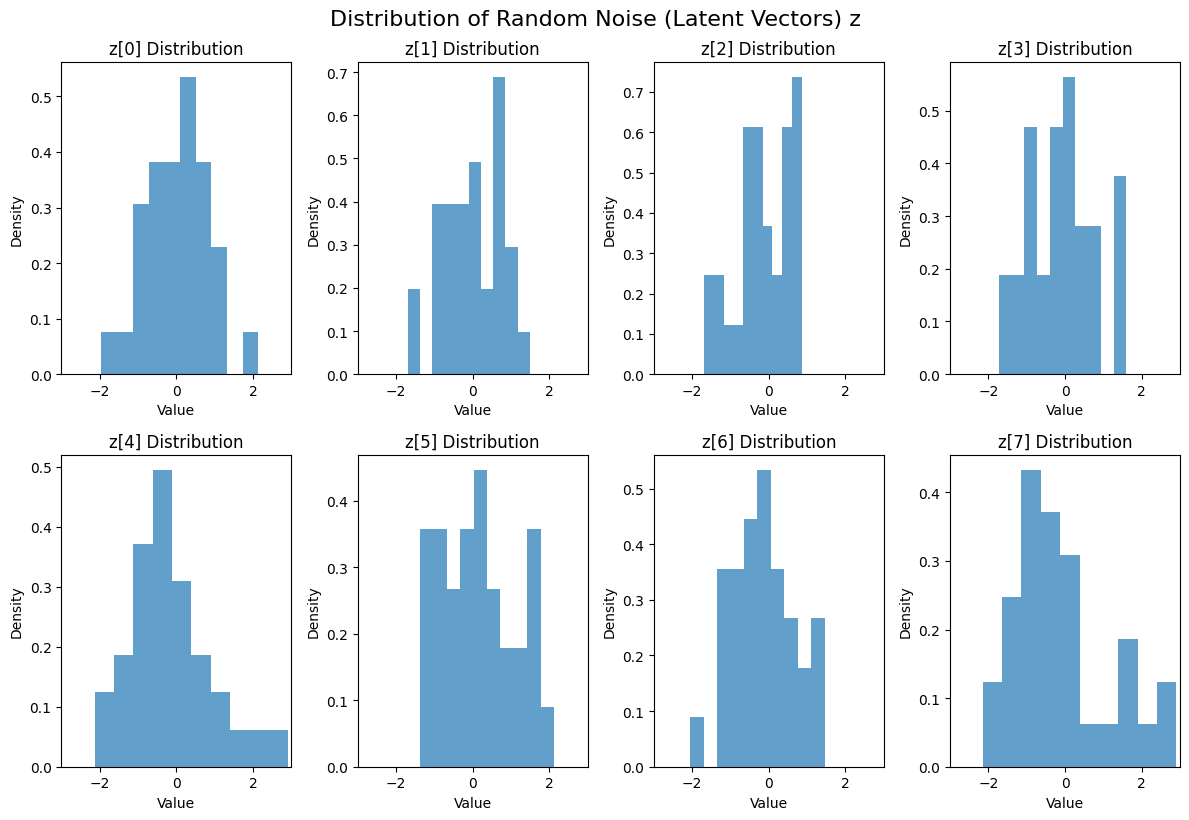

In [21]:
# ------------------------------------------------------------------
# 2. Random noise z 시각화를 도수분포(Histogram)로
# ------------------------------------------------------------------
plt.figure(figsize=(12, 8))
for i in range(n_samples):
    plt.subplot(2, 4, i + 1)  # 2행 4열로 구성
    plt.hist(z[i], bins=10, density=True, alpha=0.7) # 도수분포 (히스토그램)
    plt.title(f'z[{i}] Distribution')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.xlim(-3, 3) # x축 범위를 고정하여 비교 용이
plt.tight_layout()
plt.suptitle('Distribution of Random Noise (Latent Vectors) z', y=1.02, fontsize=16)
plt.show()

In [22]:
# ------------------------------------------------------------------
# 3. 아주 단순한 "Generative Model" G(z) 정의
#    실제 VAE/GAN/Diffusion 학습 없이, 개념 시연을 위해
#    고정된 랜덤 가중치 행렬로 노이즈를 이미지 공간으로 매핑
#    (같은 z를 넣으면 항상 같은 이미지가 나오는 결정적 함수지만,
#     z 자체가 확률분포에서 나오므로 결과적으로 매번 다른 샘플이 생성)
# ------------------------------------------------------------------
def build_fixed_generator(latent_dim, img_size, rng):
    """고정된 랜덤 가중치를 갖는 2-layer 매핑 함수."""
    hidden_dim = 128
    W1 = rng.normal(0, 1 / np.sqrt(latent_dim), size=(latent_dim, hidden_dim))
    b1 = rng.normal(0, 0.1, size=(hidden_dim,))
    W2 = rng.normal(0, 1 / np.sqrt(hidden_dim), size=(hidden_dim, img_size * img_size))
    b2 = rng.normal(0, 0.1, size=(img_size * img_size,))

    def generator(z_batch):
        h = np.tanh(z_batch @ W1 + b1)          # 은닉층 (비선형 매핑)
        out = np.tanh(h @ W2 + b2)              # 출력층 -> [-1, 1] 범위
        images = out.reshape(-1, img_size, img_size)
        # 시각화를 위해 [0, 1] 범위로 정규화
        images = (images - images.min()) / (images.max() - images.min())
        return images

    return generator

generator = build_fixed_generator(latent_dim, img_size, rng)
generated_samples = generator(z)   # sampling: noise -> generated sample
print("Generated samples shape:", generated_samples.shape)

Generated samples shape: (8, 28, 28)


시각화 이미지 저장 완료: gaussian_noise_generative_demo.png


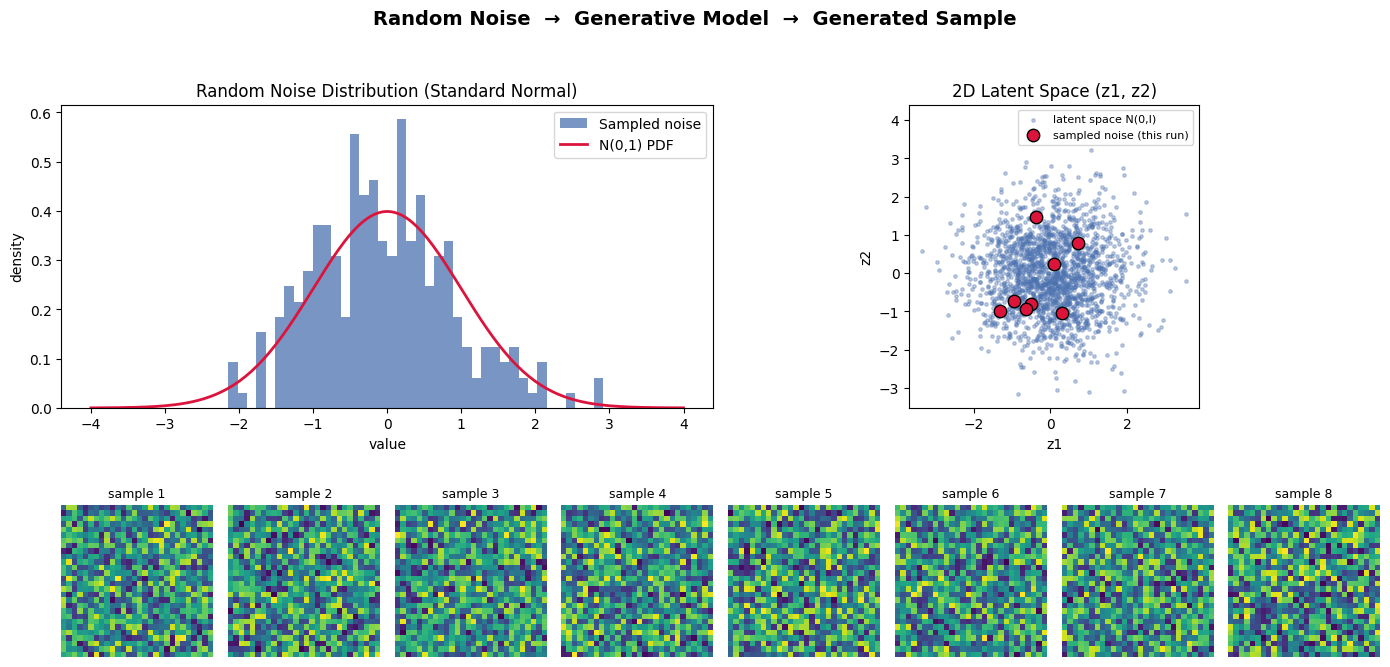

In [23]:
# ------------------------------------------------------------------
# 4. 시각화
#    (a) Random noise 분포 히스토그램 (정규분포 확인)
#    (b) 2차원으로 축소한 latent space 산점도
#    (c) Random noise -> Generative model -> Generated sample 결과
# ------------------------------------------------------------------
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, n_samples, height_ratios=[1, 1.3])

# (a) 히스토그램: z의 모든 원소가 N(0,1)을 따르는지 확인
ax_hist = fig.add_subplot(gs[0, :4])
ax_hist.hist(z.flatten(), bins=40, density=True, color="#4C72B0", alpha=0.75, label="Sampled noise")
x_axis = np.linspace(-4, 4, 200)
pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_axis ** 2)
ax_hist.plot(x_axis, pdf, color="crimson", linewidth=2, label="N(0,1) PDF")
ax_hist.set_title("Random Noise Distribution (Standard Normal)")
ax_hist.set_xlabel("value")
ax_hist.set_ylabel("density")
ax_hist.legend()

# (b) 2차원 latent space 산점도 (처음 두 차원만 사용)
ax_scatter = fig.add_subplot(gs[0, 4:])
z_big = rng.normal(0, 1, size=(2000, 2))
ax_scatter.scatter(z_big[:, 0], z_big[:, 1], s=6, alpha=0.35, color="#4C72B0", label="latent space N(0,I)")
ax_scatter.scatter(z[:, 0], z[:, 1], s=80, color="crimson", edgecolor="k", zorder=5, label="sampled noise (this run)")
ax_scatter.set_title("2D Latent Space (z1, z2)")
ax_scatter.set_xlabel("z1")
ax_scatter.set_ylabel("z2")
ax_scatter.legend(loc="upper right", fontsize=8)
ax_scatter.set_aspect("equal")

# (c) Random noise -> Generative Model -> Generated sample
for i in range(n_samples):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(generated_samples[i], cmap="viridis")
    ax.set_title(f"sample {i+1}", fontsize=9)
    ax.axis("off")

fig.suptitle("Random Noise  →  Generative Model  →  Generated Sample", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
print("시각화 이미지 저장 완료: gaussian_noise_generative_demo.png")

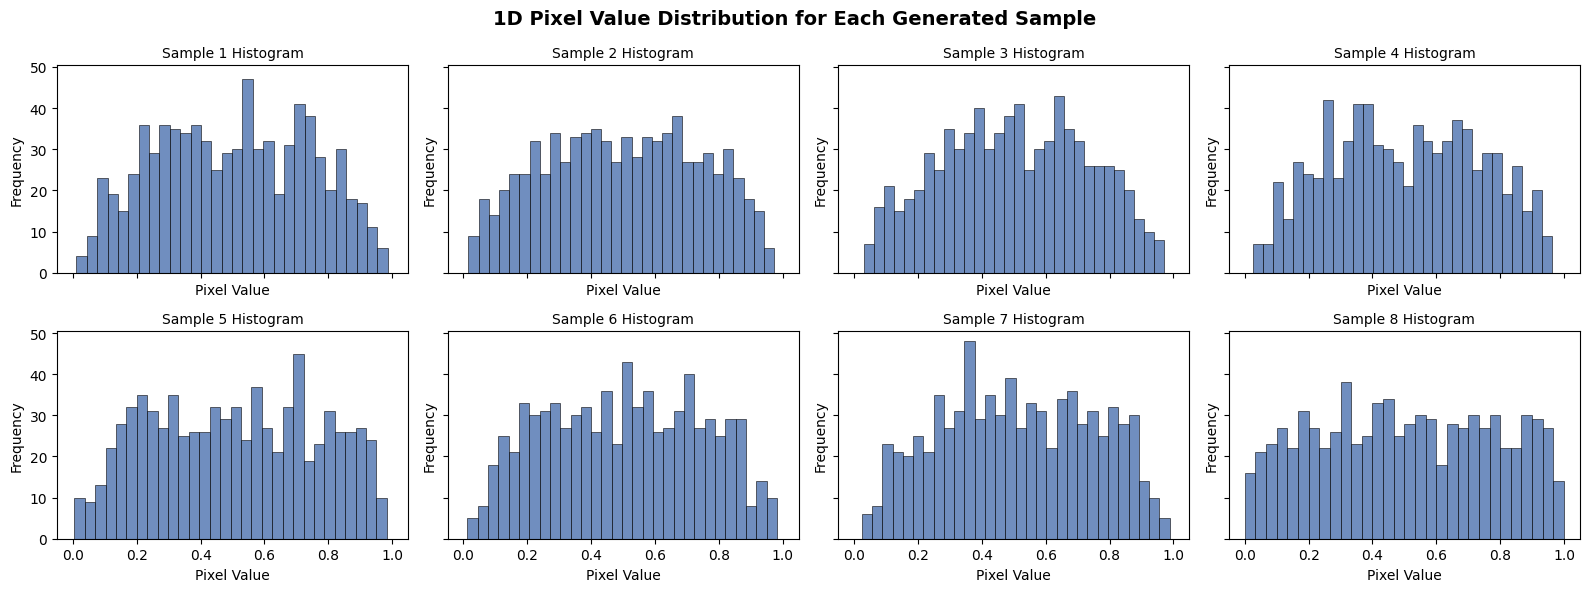

In [24]:
# ------------------------------------------------------------------
# 5. 시각화
#    (c) Random noise -> Generative model -> Generated sample 결과 대신
#        8개 샘플 각각의 1D 픽셀 값 히스토그램 시각화
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_samples):
    # 각 이미지의 픽셀 값(28x28)을 1차원 배열(784,)로 변환
    pixels = generated_samples[i].flatten()

    # 1D 히스토그램 출력
    axes[i].hist(pixels, bins=30, color="#4C72B0", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[i].set_title(f"Sample {i+1} Histogram", fontsize=10)
    axes[i].set_xlabel("Pixel Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("1D Pixel Value Distribution for Each Generated Sample", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
# @title Generative Model

z = rng.normal(loc=0.0, scale=1.0, size=(n_samples, latent_dim))

generator = build_fixed_generator(latent_dim, img_size, rng)
generated_samples = generator(z)   # sampling: noise -> generated sample

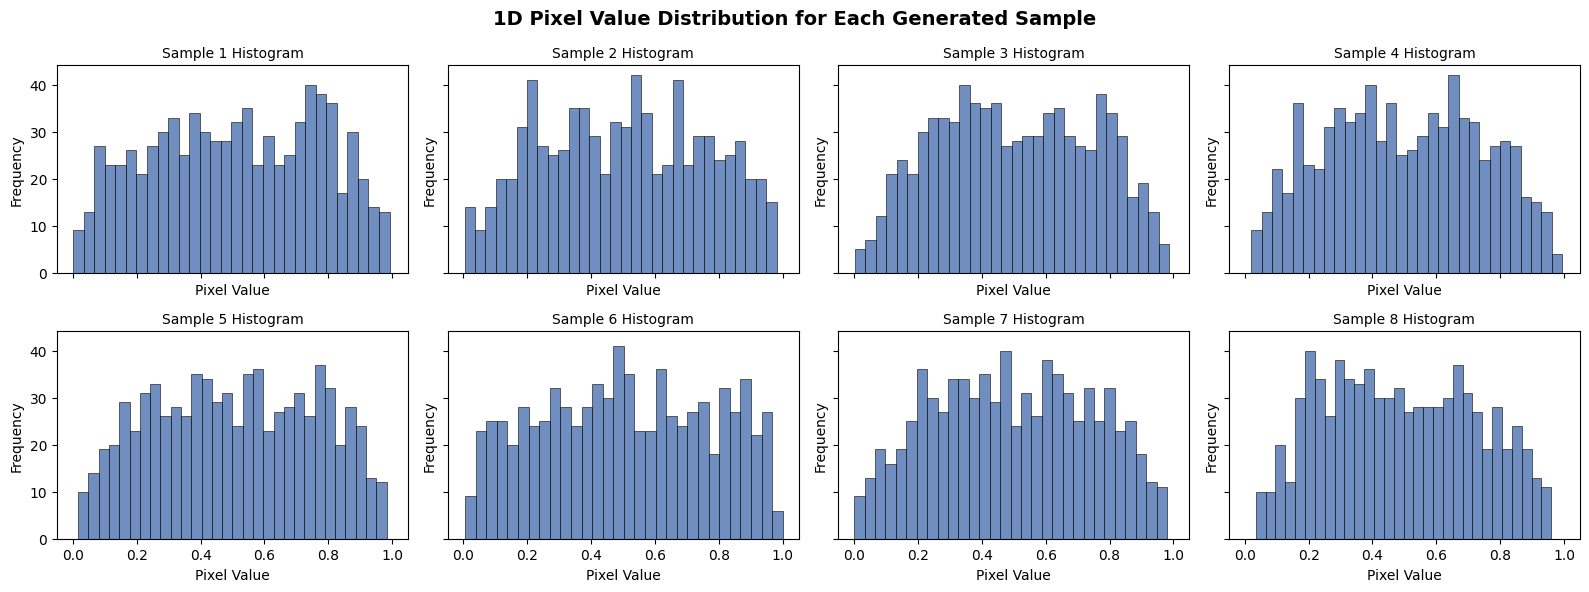

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_samples):
    # 각 이미지의 픽셀 값(28x28)을 1차원 배열(784,)로 변환
    pixels = generated_samples[i].flatten()

    # 1D 히스토그램 출력
    axes[i].hist(pixels, bins=30, color="#4C72B0", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[i].set_title(f"Sample {i+1} Histogram", fontsize=10)
    axes[i].set_xlabel("Pixel Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("1D Pixel Value Distribution for Each Generated Sample", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()